Julieta Madrigal Flores

Rodolfo Del Castillo Wilches

## Librerías

In [ ]:
from scipy.stats import norm
from scipy.optimize import brentq, newton
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date

##  Modelo Black-Scholes

In [ ]:
def bs_price(S, K, r, T, sigma, option="call"):
    # Si sigma o T son inválidos, regresa el valor intrínseco
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)

    # Fórmula de Black-Scholes
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

## Vega

In [ ]:
def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

## Volatilidad Implícita

In [ ]:
def implied_vol(price_mkt, S, K, r, T, option="call", tol=1e-8, maxiter=100):

    # 1. Validar que el precio esté dentro de los límites teóricos de no-arbitraje
    if option == "call":
        lower = max(0.0, S - K * np.exp(-r * T))
        upper = S
    else:
        lower = max(0.0, K * np.exp(-r * T) - S)
        upper = K * np.exp(-r * T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio fuera de rango teórico [{lower:.4f},{upper:.4f}]")

    # 2. Función objetivo: queremos encontrar sigma tal que BS(sigma) = precio_mercado
    f = lambda sig: bs_price(S, K, r, T, sig, option) - price_mkt

    # 3. Buscar intervalo [a, b] donde f cambia de signo (requisito de Brent)
    a, b = 1e-6, 5.0
    if f(a) * f(b) > 0:
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            if f(a) * f(b_try) <= 0:
                b = b_try
                break

    # 4. Brent: solver principal, robusto y garantiza convergencia
    try:
        return brentq(f, a, b, xtol=tol, maxiter=maxiter)
    except Exception:
        pass

    # 5. Newton-Raphson: respaldo, más rápido pero puede fallar si la semilla es mala
    try:
        iv = newton(f, x0=sigma_hist,
                    fprime=lambda s: bs_vega(S, K, r, T, s),
                    tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar la IV con ningún método.")

## Datos dinámicos de mercado

In [ ]:
# Parámetros del notebook de clase (Notion)
ticker = 'SPY'
exp    = '2026-04-17'
r      = 0.0428
today  = date.today()

# S0: precio spot real, último cierre disponible
tk   = yf.Ticker(ticker)
data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']
S0   = float(data.iloc[-1])

# T: días calendario hasta vencimiento, convertido a años
T = (date.fromisoformat(exp) - today).days / 365

# sigma_hist: volatilidad histórica anualizada — sirve como semilla para Newton-Raphson
daily_returns = data.pct_change().dropna()
sigma_hist    = float(daily_returns.std() * np.sqrt(252))

print(f"S0         = {S0:.2f}")
print(f"T          = {T:.4f} años ({round(T*365)} días)")
print(f"r          = {r:.1%}")
print(f"sigma_hist = {sigma_hist:.2%}")

/tmp/ipykernel_434/637460881.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']


S0         = 659.80
T          = 0.0767 años (28 días)
r          = 4.3%
sigma_hist = 17.77%


/tmp/ipykernel_434/637460881.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0   = float(data.iloc[-1])
/tmp/ipykernel_434/637460881.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_hist    = float(daily_returns.std() * np.sqrt(252))


## Loop sobre múltiples strikes

In [ ]:
# Rango de strikes pedido por la tarea: [S0 × 0.88, S0 × 1.10]
K_min = S0 * 0.88
K_max = S0 * 1.10

# Cargar cadena de calls para el vencimiento 2026-04-17
chain_calls = tk.option_chain(exp).calls.copy()

# Filtrar: solo strikes dentro del rango y con liquidez (bid > 0, ask > 0)
chain_f = chain_calls[
    (chain_calls['strike'] >= K_min) &
    (chain_calls['strike'] <= K_max) &
    (chain_calls['bid']    >  0)     &
    (chain_calls['ask']    >  0)
].copy()

# Precio mid dinámico: más estable que el último trade (igual que en clase)
chain_f['mid'] = (chain_f['bid'] + chain_f['ask']) / 2

# Calcular IV para cada strike
records = []

for _, row in chain_f.iterrows():
    K_i   = row['strike']
    mid_i = row['mid']

    try:
        iv_i = implied_vol(mid_i, S0, K_i, r, T, option='call')
        if 0.01 <= iv_i <= 3.0:   # descartar IVs absurdas
            records.append({
                'Strike' : K_i,
                'Bid'    : row['bid'],
                'Ask'    : row['ask'],
                'Mid'    : mid_i,
                'IV (%)' : round(iv_i * 100, 2)
            })
    except Exception:
        pass   # saltar strikes sin solución convergente

df_iv = pd.DataFrame(records).reset_index(drop=True)
print(f"Strikes con IV calculada: {len(df_iv)}")

Strikes con IV calculada: 105


## Tabla

In [ ]:
print(f"S0 = {S0:.2f}\n")

df_display = df_iv.copy()
df_display['Strike'] = df_display['Strike'].map('{:.1f}'.format)
df_display['Bid']    = df_display['Bid'].map('{:.2f}'.format)
df_display['Ask']    = df_display['Ask'].map('{:.2f}'.format)
df_display['Mid']    = df_display['Mid'].map('{:.2f}'.format)
df_display['IV (%)'] = df_display['IV (%)'].map('{:.2f}%'.format)

display(df_display)

S0 = 659.80



,Strike,Bid,Ask,Mid,IV (%)
0,585.0,76.86,79.53,78.19,29.81%
1,590.0,71.76,74.84,73.30,28.57%
2,595.0,67.08,70.39,68.73,28.52%
3,600.0,62.81,65.47,64.14,28.10%
4,605.0,58.17,60.91,59.54,27.48%
...,...,...,...,...,...
100,721.0,0.09,0.11,0.10,13.53%
101,722.0,0.08,0.10,0.09,13.54%
102,723.0,0.08,0.10,0.09,13.72%
103,724.0,0.07,0.09,0.08,13.70%


## Gráfica

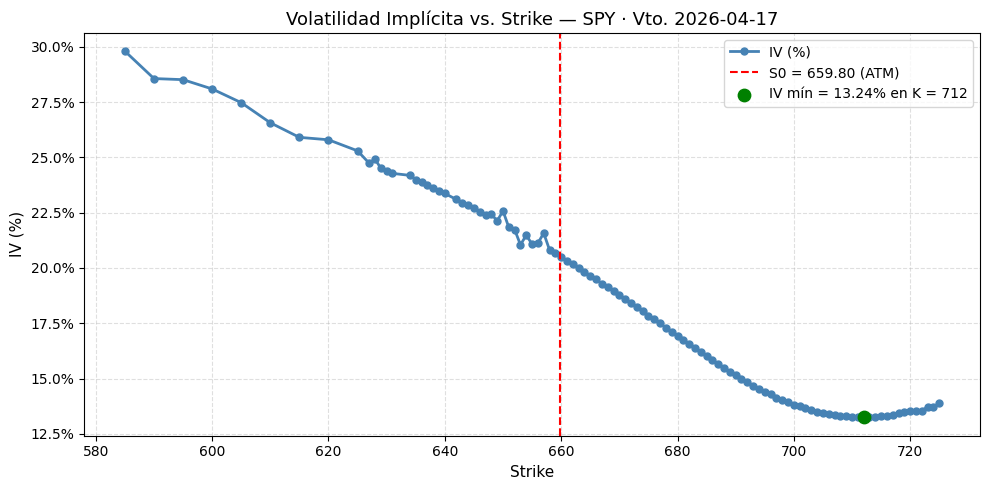


IV mínima : 13.24% en K = 712
S0        : 659.80


In [ ]:
strikes = df_iv['Strike'].values
ivs     = df_iv['IV (%)'].values

fig, ax = plt.subplots(figsize=(10, 5))

# Curva IV vs Strike
plt.plot(strikes, ivs, marker='o', color='steelblue',
         linewidth=2, markersize=5, label='IV (%)')

# Línea vertical en S0 marcando el precio ATM
plt.axvline(x=S0, color='red', linestyle='--', linewidth=1.5,
            label=f'S0 = {S0:.2f} (ATM)')

# Punto verde en el strike con IV mínima
idx_min = np.argmin(ivs)
plt.scatter([strikes[idx_min]], [ivs[idx_min]], color='green',
            zorder=5, s=80,
            label=f'IV mín = {ivs[idx_min]:.2f}% en K = {strikes[idx_min]:.0f}')

ax.set_title(f'Volatilidad Implícita vs. Strike — {ticker} · Vto. {exp}', fontsize=13)
ax.set_xlabel('Strike', fontsize=11)
ax.set_ylabel('IV (%)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nIV mínima : {ivs[idx_min]:.2f}% en K = {strikes[idx_min]:.0f}")
print(f"S0        : {S0:.2f}")



## Respuestas - Análisis de la Curva de Volatilidad Implícita

**¿La curva es decreciente, creciente o tiene forma de smile?**
En los resultados que obtuve, se observa claramente un sesgo negativo. Esto significa que la volatilidad implícita es mucho más alta para los strikes más bajos y va bajando a medida que el strike sube.

**¿En qué strike es mínima la IV? ¿Coincide con S0?**
La IV mínima no coincide exactamente con el precio spot ($S_0$), sino que se desplaza un poco hacia la derecha, situándose cerca del precio Forward.

Esto tiene sentido porque el precio forward incorpora la tasa libre de riesgo y el tiempo al vencimiento. Es el punto donde el mercado se siente neutral, y a partir de ahí, cualquier alejamiento hacia strikes más bajos dispara el costo de protección, elevando la IV.

**¿Qué compran los inversores que pagan IV alta en strikes bajos?**
Compran protección contra caídas severas (*tail risk hedging*). Las puts
profundas OTM funcionan como seguro ante crashes extremos. La demanda
estructural de cobertura por fondos institucionales eleva permanentemente
la IV en strikes bajos.

**¿Qué le dice esta curva a quien usa Black-Scholes con σ constante?**
Que Black-Scholes es internamente inconsistente con los precios de mercado:
si existiera una sola σ constante, todos los strikes producirían la misma IV.La curva muestra que cada strike requiere una volatilidad diferente. La
solución es usar superficies de volatilidad o modelos estocásticos como
Heston o SABR.